In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Load the cleaned data
df = pd.read_parquet("../data/clean_listings.parquet")

# Select the variables for Linear Regression
X_cols = ['bedrooms', 'beds', 'baths', 'amenities_count', 'photos_count', 'rating_overall']
y_col = 'ttm_revenue'

# Filter the final rows and drop missing values
df_ml = df[X_cols + [y_col]].dropna()

X = df_ml[X_cols]
y = df_ml[y_col]

In [6]:
# Train/test split and model training
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)

# Get predictions for the test set
y_pred = model.predict(X_test)

# Model results
print(f"Model R2 score: {model.score(X_test, y_test):.4f}")

# This shows how much each feature contributes (the coefficients)
coeffs = pd.DataFrame({'Feature': X_cols, 'Impact in €': model.coef_})
print(coeffs)

Model R2 score: 0.2392
           Feature   Impact in €
0         bedrooms   4288.251538
1             beds    382.564968
2            baths   7219.703551
3  amenities_count    155.302097
4     photos_count     88.479336
5   rating_overall  14947.670469


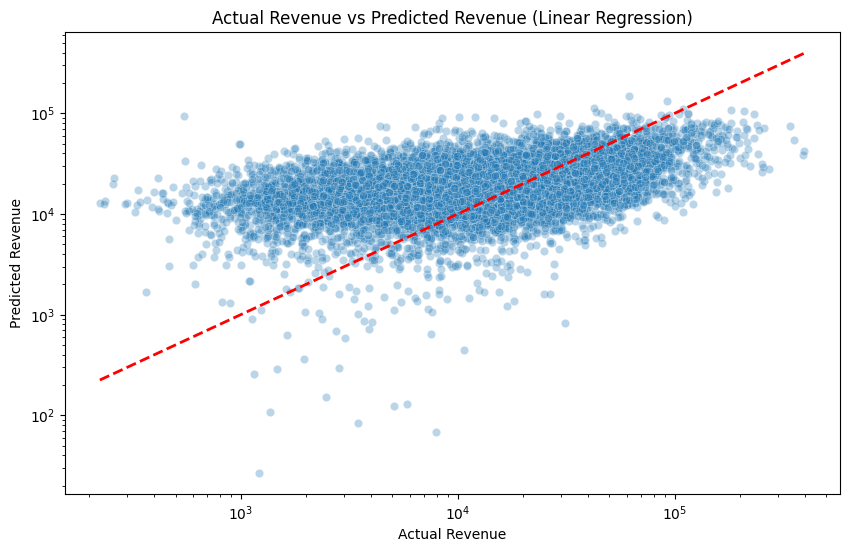

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2)
plt.title("Actual Revenue vs Predicted Revenue (Linear Regression)")
plt.xlabel("Actual Revenue")
plt.ylabel("Predicted Revenue")
plt.xscale('log') # Usamos escala log por la naturaleza de los datos de Airbnb
plt.yscale('log')
plt.show()